# 03_token_probe_block_analysis_mel_nv

For each of the 12 transformer blocks and each of the 196 spatial patch positions (14×14 grid), you train a tiny logistic regression on the single patch token at that position and measure how well it alone classifies MEL vs NV. The heatmap color at each grid cell = classification performance of that one spatial token. The white × marks the image center.

Goal:
- Freeze the fine-tuned CLS and GAP models.
- Extract patch-token features from every transformer block.
- Train one linear probe per token location.
- Evaluate token-wise accuracy and balanced accuracy on the test set.
- Visualize where class-discriminative information is available in the representation.

Important interpretation:
- This is **not CAM**.
- This is **not attention**.
- It shows how predictive each spatial patch token is if used alone.
- High center values may partly reflect HAM10000 lesion-centered dataset bias.


## 0. Configuration

Default setup:
- CSV: `data/HAM10000/mel_nv/ham_mel_nv_clean.csv`
- label column: `binary_label`, where `MEL=0`, `NV=1`
- CLS checkpoint: `external/checkpoints4/checkpoint-best-cls.pth`
- GAP checkpoint: `external/checkpoints4/checkpoint-best-gap.pth`
- all 12 PanDerm Base blocks


In [1]:
from pathlib import Path
import sys
import os
import random
import warnings
from collections import OrderedDict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

warnings.filterwarnings("ignore")

# Notebook location: notebooks/mel_nv/03_token_probe_block_analysis_mel_nv.ipynb
# REPO_ROOT = Path("../..").resolve() # local notebook
REPO_ROOT = Path("..").resolve() # ubelix notebook
REPO_ROOT = REPO_ROOT / "master-thesis"
PANDERM_CLASSIFICATION_DIR = REPO_ROOT / "external" / "PanDerm" / "classification"

CSV_PATH = REPO_ROOT / "data" / "HAM10000" / "mel_nv" / "ham_mel_nv_clean.csv"
ROOT_PATH = REPO_ROOT / "data" / "HAM10000"

NB_CLASSES = 2
CLASS_NAMES = ["MEL", "NV"]
LABEL_COL = "binary_label"
IMAGE_COL = "image_rel_path"

IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 4
SEED = 0

# PanDerm Base has 12 blocks: 0..11.
# This is the quantitative counterpart to the qualitative block notebook.
SELECTED_BLOCKS = list(range(12))
# SELECTED_BLOCKS = [-1, -2, -4, -6, -8, -10, -12]

# Runtime control:
# - set MAX_TRAIN_SAMPLES = 1000 for quick debugging
# - set MAX_TRAIN_SAMPLES = None for final run
MAX_TRAIN_SAMPLES = None
MAX_TEST_SAMPLES = None

# "sgd" is much faster. "logreg" is slower but more standard.
PROBE_TYPE = "sgd"

OUT_ROOT = REPO_ROOT / "outputs" / "mel_nv" / "token_probe_block_analysis"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

SCENARIOS = [
    {
        "name": "CLS HA 5.0",
        "short_name": "cls_ha5",
        "checkpoint": REPO_ROOT / "external" / "checkpoints5" / "checkpoint-best-cls-ha5.pth",
        "use_mean_pooling": False,
        "pooling_name": "CLS token pooling",
    },
    {
        "name": "GAP HA 5.0",
        "short_name": "gap_ha5",
        "checkpoint": REPO_ROOT / "external" / "checkpoints5" / "checkpoint-best-gap-ha5.pth",
        "use_mean_pooling": True,
        "pooling_name": "GAP / mean pooling",
    },
]

if str(PANDERM_CLASSIFICATION_DIR) not in sys.path:
    sys.path.insert(0, str(PANDERM_CLASSIFICATION_DIR))

print("REPO_ROOT:", REPO_ROOT)
print("CSV exists:", CSV_PATH.exists(), CSV_PATH)
print("ROOT exists:", ROOT_PATH.exists(), ROOT_PATH)
print("OUT_ROOT:", OUT_ROOT)
for s in SCENARIOS:
    print("\n", s["name"])
    print("  checkpoint exists:", Path(s["checkpoint"]).exists(), s["checkpoint"])
    print("  use_mean_pooling:", s["use_mean_pooling"])


REPO_ROOT: /storage/homefs/cn21m021/projects/master-thesis
CSV exists: True /storage/homefs/cn21m021/projects/master-thesis/data/HAM10000/mel_nv/ham_mel_nv_clean.csv
ROOT exists: True /storage/homefs/cn21m021/projects/master-thesis/data/HAM10000
OUT_ROOT: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/token_probe_block_analysis

 CLS HA 5.0
  checkpoint exists: True /storage/homefs/cn21m021/projects/master-thesis/external/checkpoints5/checkpoint-best-cls-ha5.pth
  use_mean_pooling: False

 GAP HA 5.0
  checkpoint exists: True /storage/homefs/cn21m021/projects/master-thesis/external/checkpoints5/checkpoint-best-gap-ha5.pth
  use_mean_pooling: True


In [2]:
def seed_everything(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("DEVICE:", DEVICE)


DEVICE: cuda


## 1. Dataset and transforms

This uses stable evaluation transforms. No heavy augmentation is used because we want stable feature extraction.

In [3]:
class CSVDermDataset(Dataset):
    def __init__(self, df, root_path, transform=None, image_col="image_rel_path", label_col="binary_label"):
        self.df = df.reset_index(drop=True)
        self.root_path = Path(root_path)
        self.transform = transform
        self.image_col = image_col
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def resolve_path(self, value):
        p = Path(str(value))
        if p.is_absolute():
            return p
        return (self.root_path / p).resolve()

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.resolve_path(row[self.image_col])
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        label = int(row[self.label_col])
        image_id = str(row["image_id"]) if "image_id" in row.index else Path(str(row[self.image_col])).stem
        return img, label, image_id


eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

df = pd.read_csv(CSV_PATH, low_memory=False)
print("CSV shape:", df.shape)
print("Columns:", list(df.columns))

required_cols = {"split", IMAGE_COL, LABEL_COL, "gt_label"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

split = df["split"].astype(str).str.lower()
train_df = df[split == "train"].copy()
val_df = df[split == "val"].copy()
test_df = df[split == "test"].copy()

# Train probes on train + val features. Test remains untouched.
probe_train_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

if MAX_TRAIN_SAMPLES is not None and len(probe_train_df) > MAX_TRAIN_SAMPLES:
    probe_train_df = probe_train_df.sample(MAX_TRAIN_SAMPLES, random_state=SEED).reset_index(drop=True)
if MAX_TEST_SAMPLES is not None and len(test_df) > MAX_TEST_SAMPLES:
    test_df = test_df.sample(MAX_TEST_SAMPLES, random_state=SEED).reset_index(drop=True)

print("Probe train:", probe_train_df.shape)
print("Test:", test_df.shape)
print("Probe train label counts:\n", probe_train_df[LABEL_COL].value_counts().sort_index())
print("Test label counts:\n", test_df[LABEL_COL].value_counts().sort_index())
print("Probe train gt counts:\n", probe_train_df["gt_label"].value_counts().sort_index())
print("Test gt counts:\n", test_df["gt_label"].value_counts().sort_index())

train_ds = CSVDermDataset(probe_train_df, ROOT_PATH, transform=eval_transform, image_col=IMAGE_COL, label_col=LABEL_COL)
test_ds = CSVDermDataset(test_df, ROOT_PATH, transform=eval_transform, image_col=IMAGE_COL, label_col=LABEL_COL)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


CSV shape: (7818, 22)
Columns: ['lesion_id', 'image_id', 'image', 'dx', 'gt_label', 'label', 'label_2class', 'binary_label', 'split', 'image_rel_path', 'mask_rel_path', 'mask_found', 'cue_applied', 'cue_mask_rel_path', 'cue_mode', 'dx_type', 'age', 'sex', 'localization', 'dataset', 'age_group', 'dx_norm']
Probe train: (6797, 22)
Test: (1021, 22)
Probe train label counts:
 binary_label
0    1043
1    5754
Name: count, dtype: int64
Test label counts:
 binary_label
0     70
1    951
Name: count, dtype: int64
Probe train gt counts:
 gt_label
MEL    1043
NV     5754
Name: count, dtype: int64
Test gt counts:
 gt_label
MEL     70
NV     951
Name: count, dtype: int64


## 2. Load PanDerm model

Important:
- CLS checkpoint uses `use_mean_pooling=False`.
- GAP checkpoint uses `use_mean_pooling=True`.
- The checkpoint decides classification weights, but the model architecture must match the pooling mode.

In [4]:
from models.modeling_finetune import panderm_base_patch16_224_finetune, panderm_large_patch16_224_finetune


def infer_variant_from_state_dict(sd: dict) -> str:
    # PanDerm Base has embed dim 768, Large has 1024.
    for key in ["cls_token", "module.cls_token", "model.cls_token"]:
        if key in sd:
            dim = sd[key].shape[-1]
            if dim == 768:
                return "base"
            if dim == 1024:
                return "large"
    # Fallback: your current experiments use Base.
    return "base"


def build_model(num_classes: int, use_mean_pooling: bool, variant: str = "base"):
    common_kwargs = dict(
        pretrained=False,
        num_classes=num_classes,
        drop_rate=0.0,
        drop_path_rate=0.0,
        attn_drop_rate=0.0,
        drop_block_rate=None,
        use_mean_pooling=use_mean_pooling,
        init_scale=1.0,
        use_rel_pos_bias=False,
        init_values=0.1,
        lin_probe=False,
    )
    if variant == "base":
        return panderm_base_patch16_224_finetune(**common_kwargs)
    elif variant == "large":
        return panderm_large_patch16_224_finetune(**common_kwargs)
    else:
        raise ValueError(f"Unknown variant: {variant}")


def unwrap_state_dict(ckpt):
    if isinstance(ckpt, dict):
        for key in ["model", "state_dict", "module"]:
            if key in ckpt and isinstance(ckpt[key], dict):
                ckpt = ckpt[key]
                break
    new_sd = OrderedDict()
    for k, v in ckpt.items():
        if k.startswith("module."):
            k = k[len("module."):]
        if k.startswith("backbone."):
            k = k[len("backbone."):]
        new_sd[k] = v
    return new_sd


def load_model_for_scenario(scenario: dict):
    ckpt = torch.load(scenario["checkpoint"], map_location="cpu")
    sd = unwrap_state_dict(ckpt)
    variant = infer_variant_from_state_dict(sd)
    model = build_model(NB_CLASSES, scenario["use_mean_pooling"], variant=variant)
    missing, unexpected = model.load_state_dict(sd, strict=False)

    print("\nLoaded", scenario["name"])
    print("  variant:", variant)
    print("  missing keys:", len(missing))
    print("  unexpected keys:", len(unexpected))
    if len(missing) < 20:
        print("  missing:", missing)
    if len(unexpected) < 20:
        print("  unexpected:", unexpected)

    model.to(DEVICE)
    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    print("  blocks:", len(model.blocks))
    print("  patch grid:", model.patch_embed.patch_shape)
    print("  use_mean_pooling:", model.use_mean_pooling)
    return model


## 3. Feature extraction from selected blocks

Forward hooks store patch tokens after each transformer block.

For PanDerm Base:
- block `0` = earliest block
- block `11` = final block
- negative CAM block `-1` corresponds to block `11`
- negative CAM block `-6` corresponds to block `6`


In [5]:
def normalize_block_indices(selected_blocks, num_blocks):
    out = []
    for b in selected_blocks:
        idx = b if b >= 0 else num_blocks + b
        if idx < 0 or idx >= num_blocks:
            raise ValueError(f"Block {b} resolves to {idx}, outside 0..{num_blocks-1}")
        out.append(idx)
    return out


@torch.no_grad()
def extract_features_for_blocks(model, loader, block_indices):
    storage = {idx: [] for idx in block_indices}
    labels = []
    image_names = []
    hooks = []

    def make_hook(idx):
        def hook(module, inputs, output):
            # output shape: [B, 1 + num_patches, C]
            patch_tokens = output[:, 1:, :].detach().cpu().float()
            storage[idx].append(patch_tokens)
        return hook

    for idx in block_indices:
        hooks.append(model.blocks[idx].register_forward_hook(make_hook(idx)))

    try:
        for batch_idx, (images, y, names) in enumerate(loader):
            images = images.to(DEVICE, non_blocking=True)
            _ = model(images)
            labels.append(y.cpu())
            image_names.extend(list(names))
            if (batch_idx + 1) % 20 == 0:
                print(f"Processed {batch_idx + 1}/{len(loader)} batches")
    finally:
        for h in hooks:
            h.remove()

    features = {idx: torch.cat(storage[idx], dim=0).numpy() for idx in block_indices}
    labels = torch.cat(labels, dim=0).numpy()
    return features, labels, image_names


## 4. Train one linear probe per token location

For each block:
- 196 token locations for 14×14 patches
- one linear classifier per token location
- evaluate accuracy and balanced accuracy on test data


In [6]:
def make_probe():
    if PROBE_TYPE == "logreg":
        return make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="lbfgs",
                n_jobs=-1,
            ),
        )
    elif PROBE_TYPE == "sgd":
        return make_pipeline(
            StandardScaler(),
            SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=1e-4,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=SEED,
            ),
        )
    else:
        raise ValueError(PROBE_TYPE)


def compute_token_probe_map(X_train, y_train, X_test, y_test, grid_shape):
    # X_* shape: [N, T, C]
    n_tokens = X_train.shape[1]
    accs = []
    bal_accs = []

    for t in range(n_tokens):
        clf = make_probe()
        clf.fit(X_train[:, t, :], y_train)
        pred = clf.predict(X_test[:, t, :])
        accs.append(accuracy_score(y_test, pred))
        bal_accs.append(balanced_accuracy_score(y_test, pred))

        if (t + 1) % 25 == 0:
            print(f"  token {t + 1}/{n_tokens}")

    acc_map = np.array(accs).reshape(grid_shape)
    bal_acc_map = np.array(bal_accs).reshape(grid_shape)
    return acc_map, bal_acc_map


def build_block_summary(results, scenario):
    rows = []
    for b, d in results.items():
        resolved_idx = d["idx"]
        # negative_index = resolved_idx - len(SELECTED_BLOCKS)
        negative_index = resolved_idx - len(model.blocks)
        for metric in ["accuracy", "balanced_accuracy"]:
            m = d[metric]
            center_value = float(m[m.shape[0] // 2, m.shape[1] // 2])
            rows.append({
                "model": scenario["name"],
                "short_name": scenario["short_name"],
                "pooling": scenario["pooling_name"],
                "use_mean_pooling": scenario["use_mean_pooling"],
                "block": b,
                "resolved_index": resolved_idx,
                "negative_index": negative_index,
                "metric": metric,
                "mean": float(m.mean()),
                "std": float(m.std()),
                "min": float(m.min()),
                "max": float(m.max()),
                "center_value": center_value,
                "spatial_contrast": float(m.max() - m.mean()),
            })
    return pd.DataFrame(rows)


## 5. Run token probe analysis for CLS and GAP

This is the main computation cell.

In [ ]:
import gc

ALL_RESULTS = {}
ALL_SUMMARIES = []

for scenario in SCENARIOS:
    print("\n" + "#" * 100)
    print("Running scenario:", scenario["name"])
    print("#" * 100)

    scenario_out_dir = OUT_ROOT / scenario["short_name"]
    scenario_out_dir.mkdir(parents=True, exist_ok=True)

    model = load_model_for_scenario(scenario)

    all_block_indices = normalize_block_indices(SELECTED_BLOCKS, len(model.blocks))
    grid_shape = model.patch_embed.patch_shape

    print("Selected/resolved blocks:", list(zip(SELECTED_BLOCKS, all_block_indices)))
    print("Grid shape:", grid_shape)

    results = {}

    for selected_block, resolved_idx in zip(SELECTED_BLOCKS, all_block_indices):
        print("\n" + "=" * 100)
        print(f"{scenario['name']} | selected block {selected_block} | resolved index {resolved_idx}")
        print("=" * 100)

        # Important:
        # Extract only ONE block at a time.
        # This avoids storing all block features in RAM simultaneously.
        current_block_indices = [resolved_idx]

        print("\nExtracting TRAIN features for this block only...")
        train_features, y_train, train_names = extract_features_for_blocks(
            model,
            train_loader,
            current_block_indices,
        )

        print("\nExtracting TEST features for this block only...")
        test_features, y_test, test_names = extract_features_for_blocks(
            model,
            test_loader,
            current_block_indices,
        )

        print(
            "Feature shapes:",
            "train", train_features[resolved_idx].shape,
            "test", test_features[resolved_idx].shape,
        )

        print("\nTraining token probes...")
        acc_map, bal_acc_map = compute_token_probe_map(
            train_features[resolved_idx],
            y_train,
            test_features[resolved_idx],
            y_test,
            grid_shape=grid_shape,
        )

        results[selected_block] = {
            "idx": resolved_idx,
            "accuracy": acc_map,
            "balanced_accuracy": bal_acc_map,
        }

        acc_path = scenario_out_dir / f"token_probe_accuracy_block_{selected_block}.npy"
        bal_acc_path = scenario_out_dir / f"token_probe_balanced_accuracy_block_{selected_block}.npy"

        np.save(acc_path, acc_map)
        np.save(bal_acc_path, bal_acc_map)

        print("Saved:", acc_path)
        print("Saved:", bal_acc_path)

        # Important memory cleanup after every block
        del train_features, test_features
        del y_train, y_test, train_names, test_names
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    summary_df = build_block_summary(results, scenario)
    summary_path = scenario_out_dir / "token_probe_summary.csv"
    summary_df.to_csv(summary_path, index=False)

    print("\nSaved summary:", summary_path)
    display(summary_df)

    ALL_RESULTS[scenario["short_name"]] = {
        "scenario": scenario,
        "results": results,
        "summary": summary_df,
        "out_dir": scenario_out_dir,
    }

    ALL_SUMMARIES.append(summary_df)

    # Clear model before next scenario
    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

combined_summary_df = pd.concat(ALL_SUMMARIES, axis=0).reset_index(drop=True)
combined_summary_path = OUT_ROOT / "token_probe_summary_combined.csv"
combined_summary_df.to_csv(combined_summary_path, index=False)

print("\nSaved combined summary:", combined_summary_path)
display(combined_summary_df)

In [8]:
# ALL_RESULTS = {}
# ALL_SUMMARIES = []

# for scenario in SCENARIOS:
#     print("\n" + "#" * 100)
#     print("Running scenario:", scenario["name"])
#     print("#" * 100)

#     scenario_out_dir = OUT_ROOT / scenario["short_name"]
#     scenario_out_dir.mkdir(parents=True, exist_ok=True)

#     model = load_model_for_scenario(scenario)
#     block_indices = normalize_block_indices(SELECTED_BLOCKS, len(model.blocks))
#     print("Selected/resolved blocks:", list(zip(SELECTED_BLOCKS, block_indices)))

#     print("\nExtracting TRAIN features...")
#     train_features, y_train, train_names = extract_features_for_blocks(model, train_loader, block_indices)

#     print("\nExtracting TEST features...")
#     test_features, y_test, test_names = extract_features_for_blocks(model, test_loader, block_indices)

#     grid_shape = model.patch_embed.patch_shape
#     print("Grid shape:", grid_shape)
#     for idx in block_indices:
#         print(idx, "train", train_features[idx].shape, "test", test_features[idx].shape)

#     results = {}
#     for selected, idx in zip(SELECTED_BLOCKS, block_indices):
#         print(f"\nTraining token probes for block {selected} / index {idx}")
#         acc_map, bal_acc_map = compute_token_probe_map(
#             train_features[idx], y_train,
#             test_features[idx], y_test,
#             grid_shape=grid_shape,
#         )
#         results[selected] = {
#             "idx": idx,
#             "accuracy": acc_map,
#             "balanced_accuracy": bal_acc_map,
#         }

#         np.save(scenario_out_dir / f"token_probe_accuracy_block_{selected}.npy", acc_map)
#         np.save(scenario_out_dir / f"token_probe_balanced_accuracy_block_{selected}.npy", bal_acc_map)

#     summary_df = build_block_summary(results, scenario)
#     summary_path = scenario_out_dir / "token_probe_summary.csv"
#     summary_df.to_csv(summary_path, index=False)
#     print("Saved summary:", summary_path)
#     display(summary_df)

#     ALL_RESULTS[scenario["short_name"]] = {
#         "scenario": scenario,
#         "results": results,
#         "summary": summary_df,
#         "out_dir": scenario_out_dir,
#     }
#     ALL_SUMMARIES.append(summary_df)

#     # Clear GPU/MPS memory between scenarios.
#     del model, train_features, test_features
#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()

# combined_summary_df = pd.concat(ALL_SUMMARIES, axis=0).reset_index(drop=True)
# combined_summary_path = OUT_ROOT / "token_probe_summary_combined.csv"
# combined_summary_df.to_csv(combined_summary_path, index=False)
# print("Saved combined summary:", combined_summary_path)
# display(combined_summary_df)


## 6. Plot heatmaps to PDF

One PDF per model and metric.

Saved PDF: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/token_probe_block_analysis/cls_ha5/token_probe_all_blocks_cls_ha5_balanced_accuracy.pdf


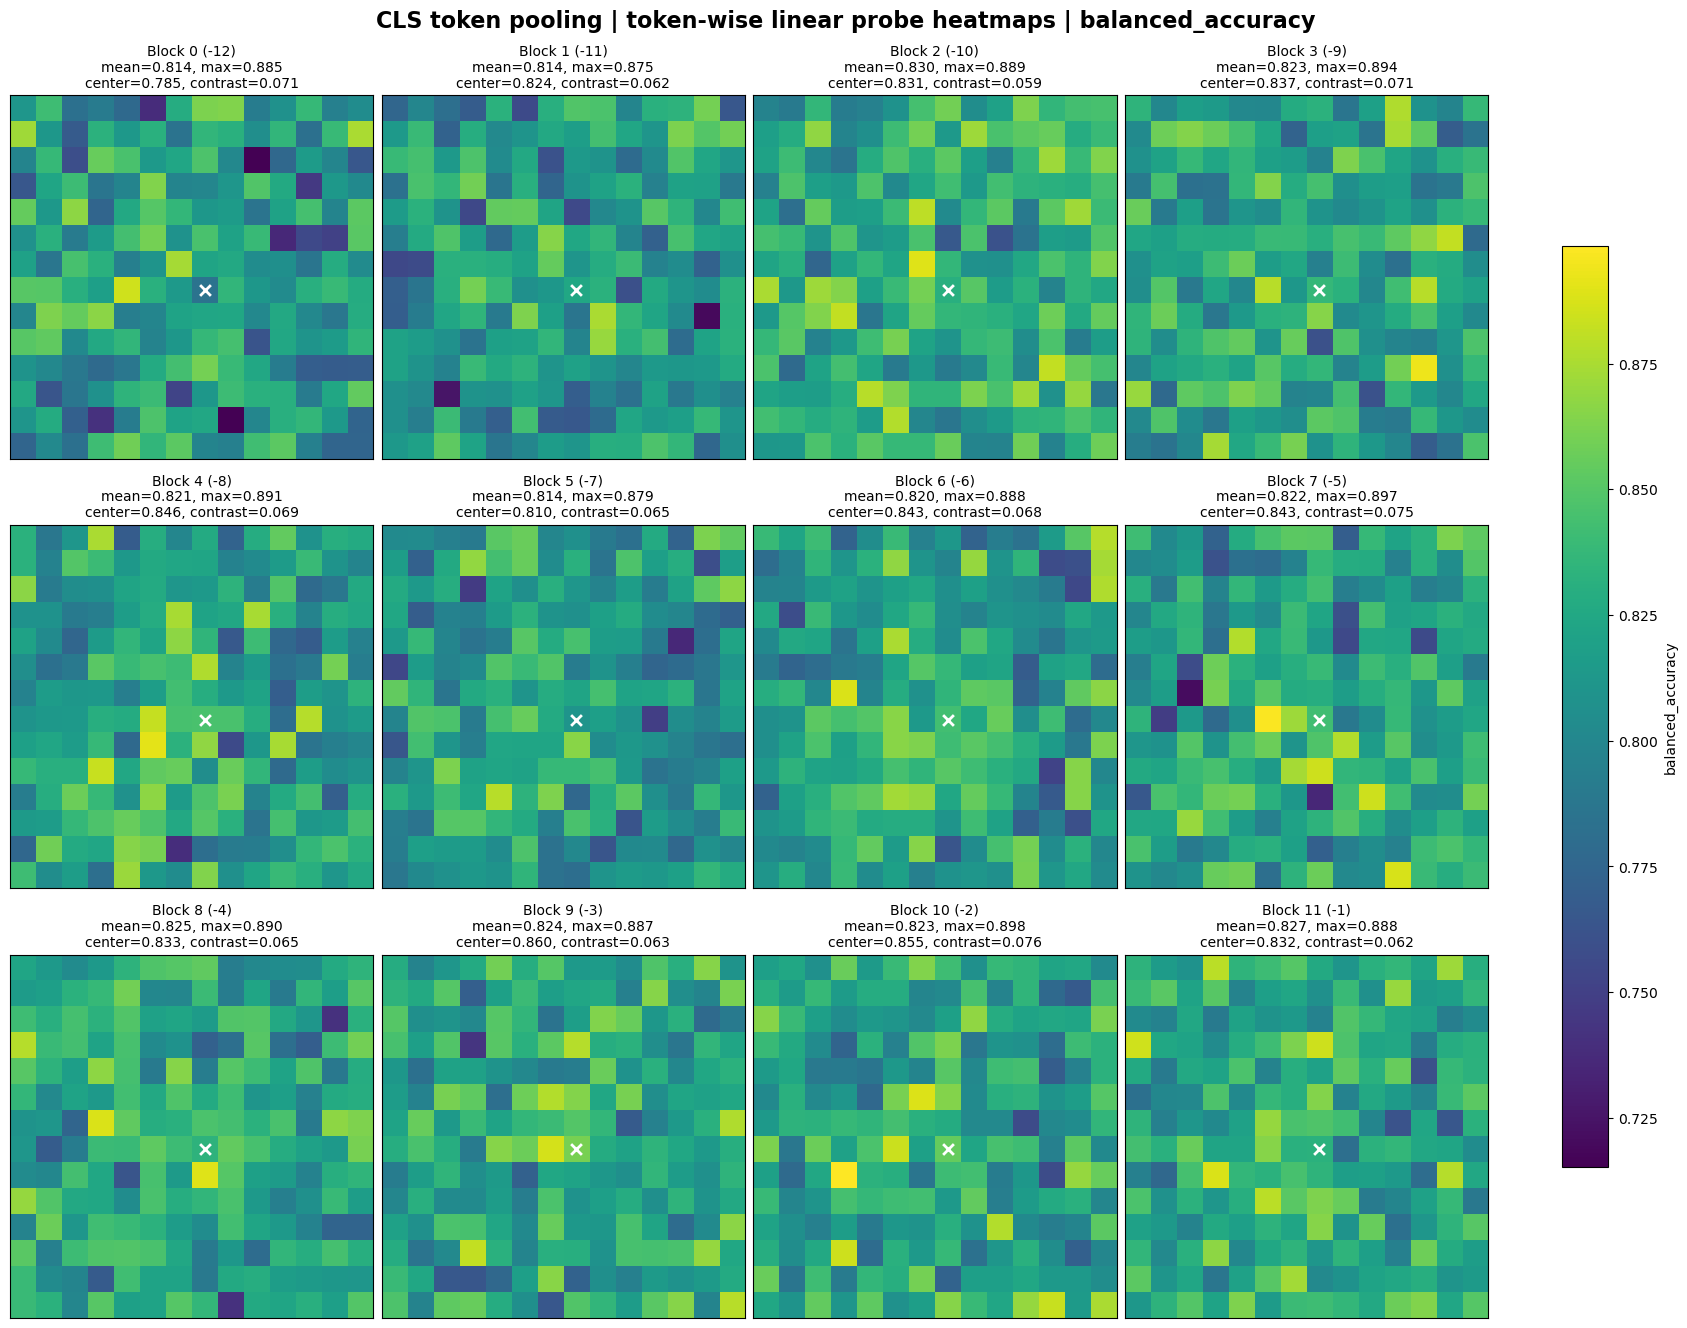

Saved PDF: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/token_probe_block_analysis/cls_ha5/token_probe_all_blocks_cls_ha5_accuracy.pdf


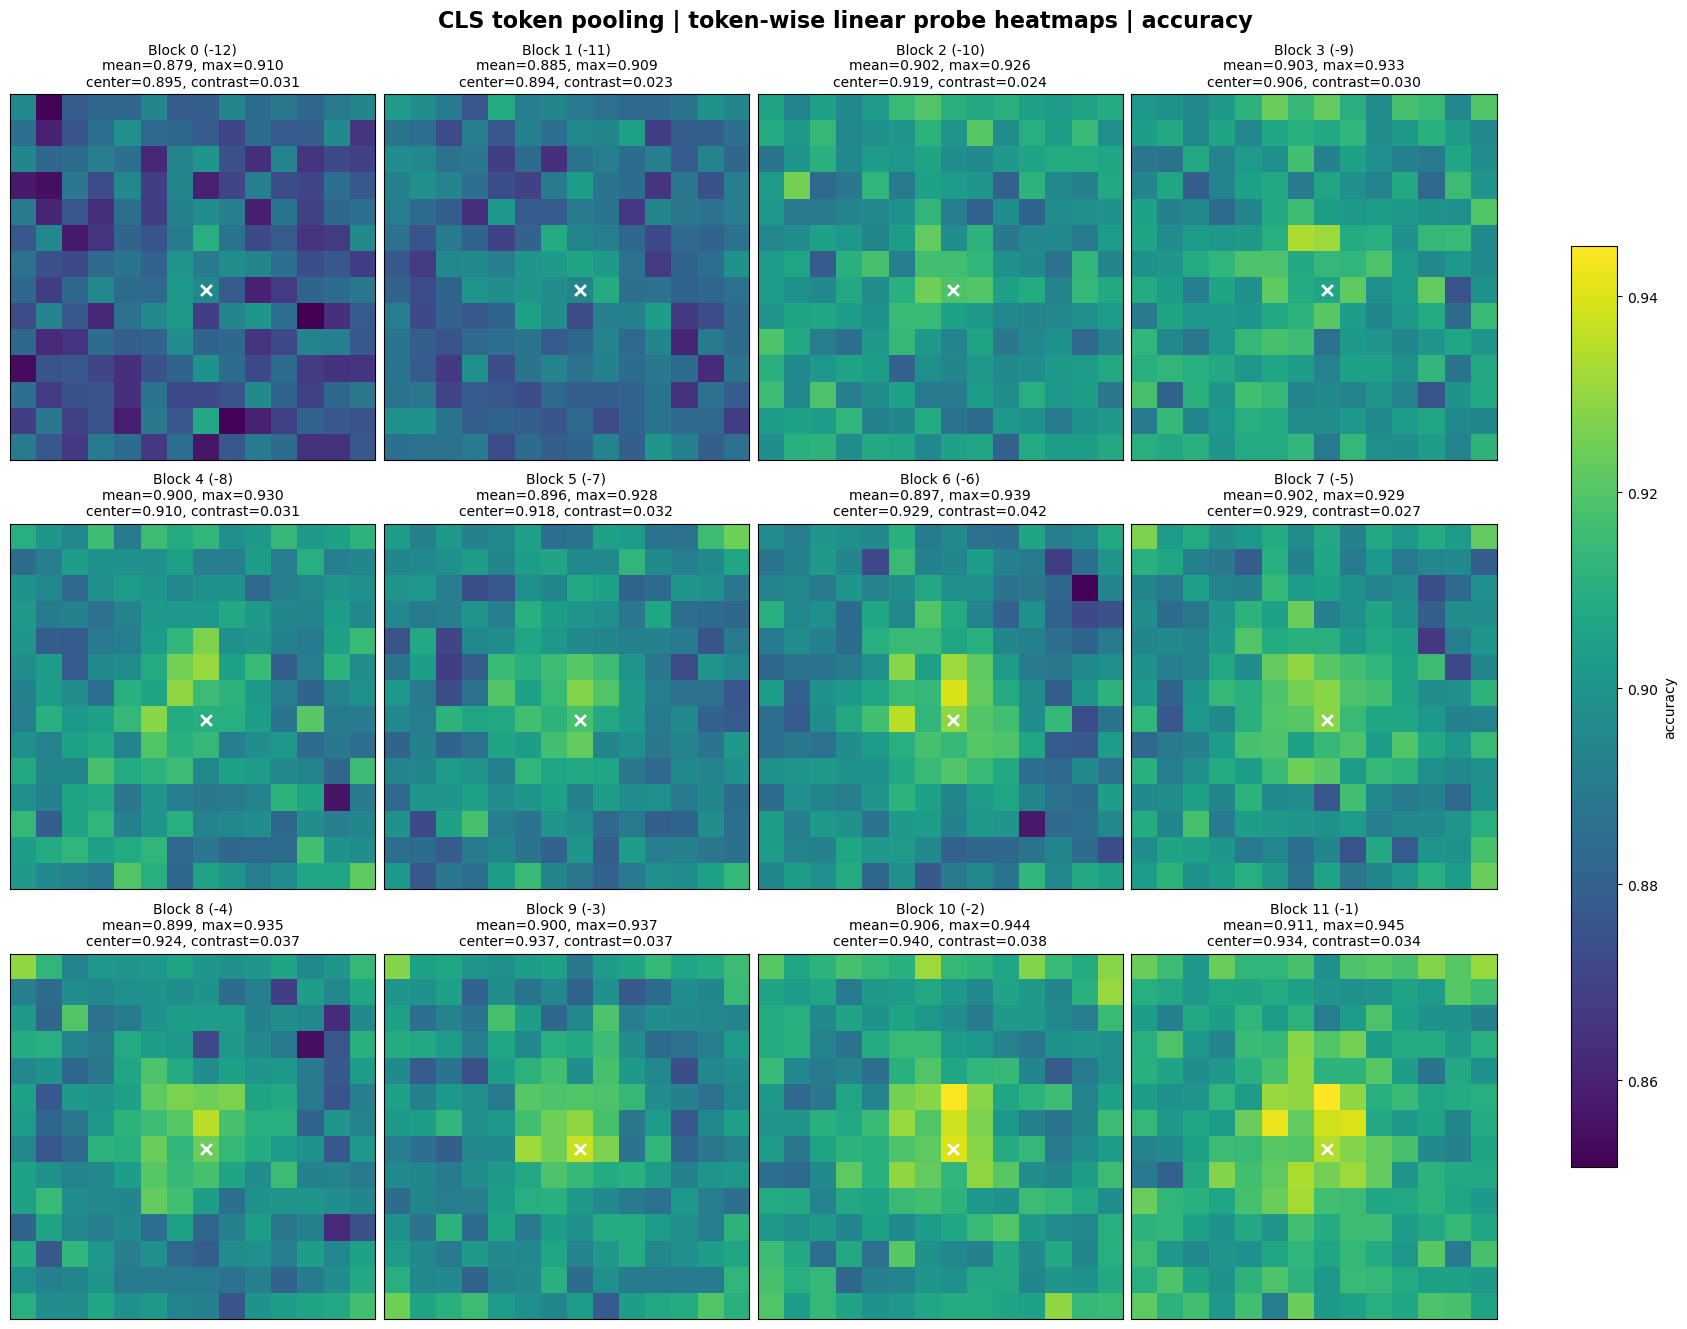

Saved PDF: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/token_probe_block_analysis/gap_ha5/token_probe_all_blocks_gap_ha5_balanced_accuracy.pdf


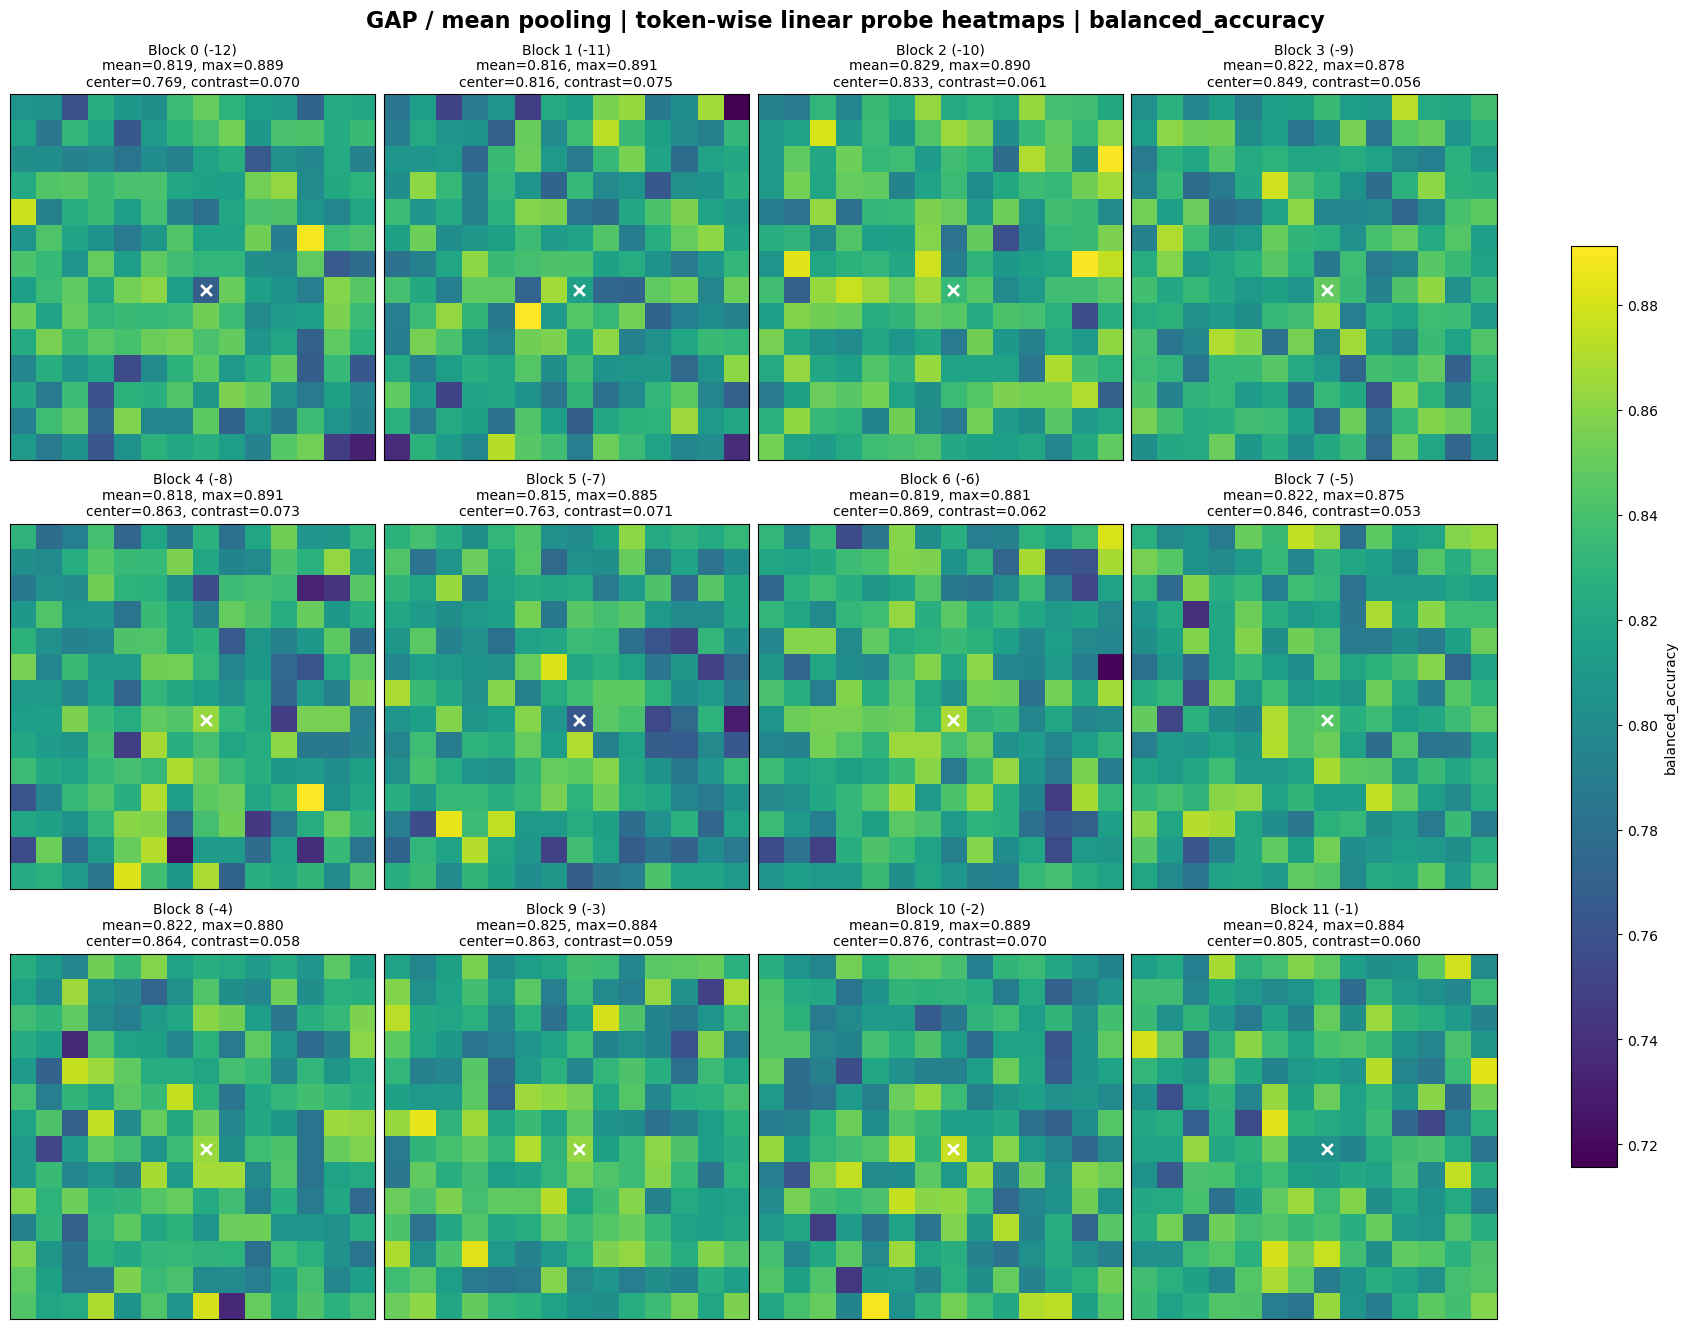

Saved PDF: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/token_probe_block_analysis/gap_ha5/token_probe_all_blocks_gap_ha5_accuracy.pdf


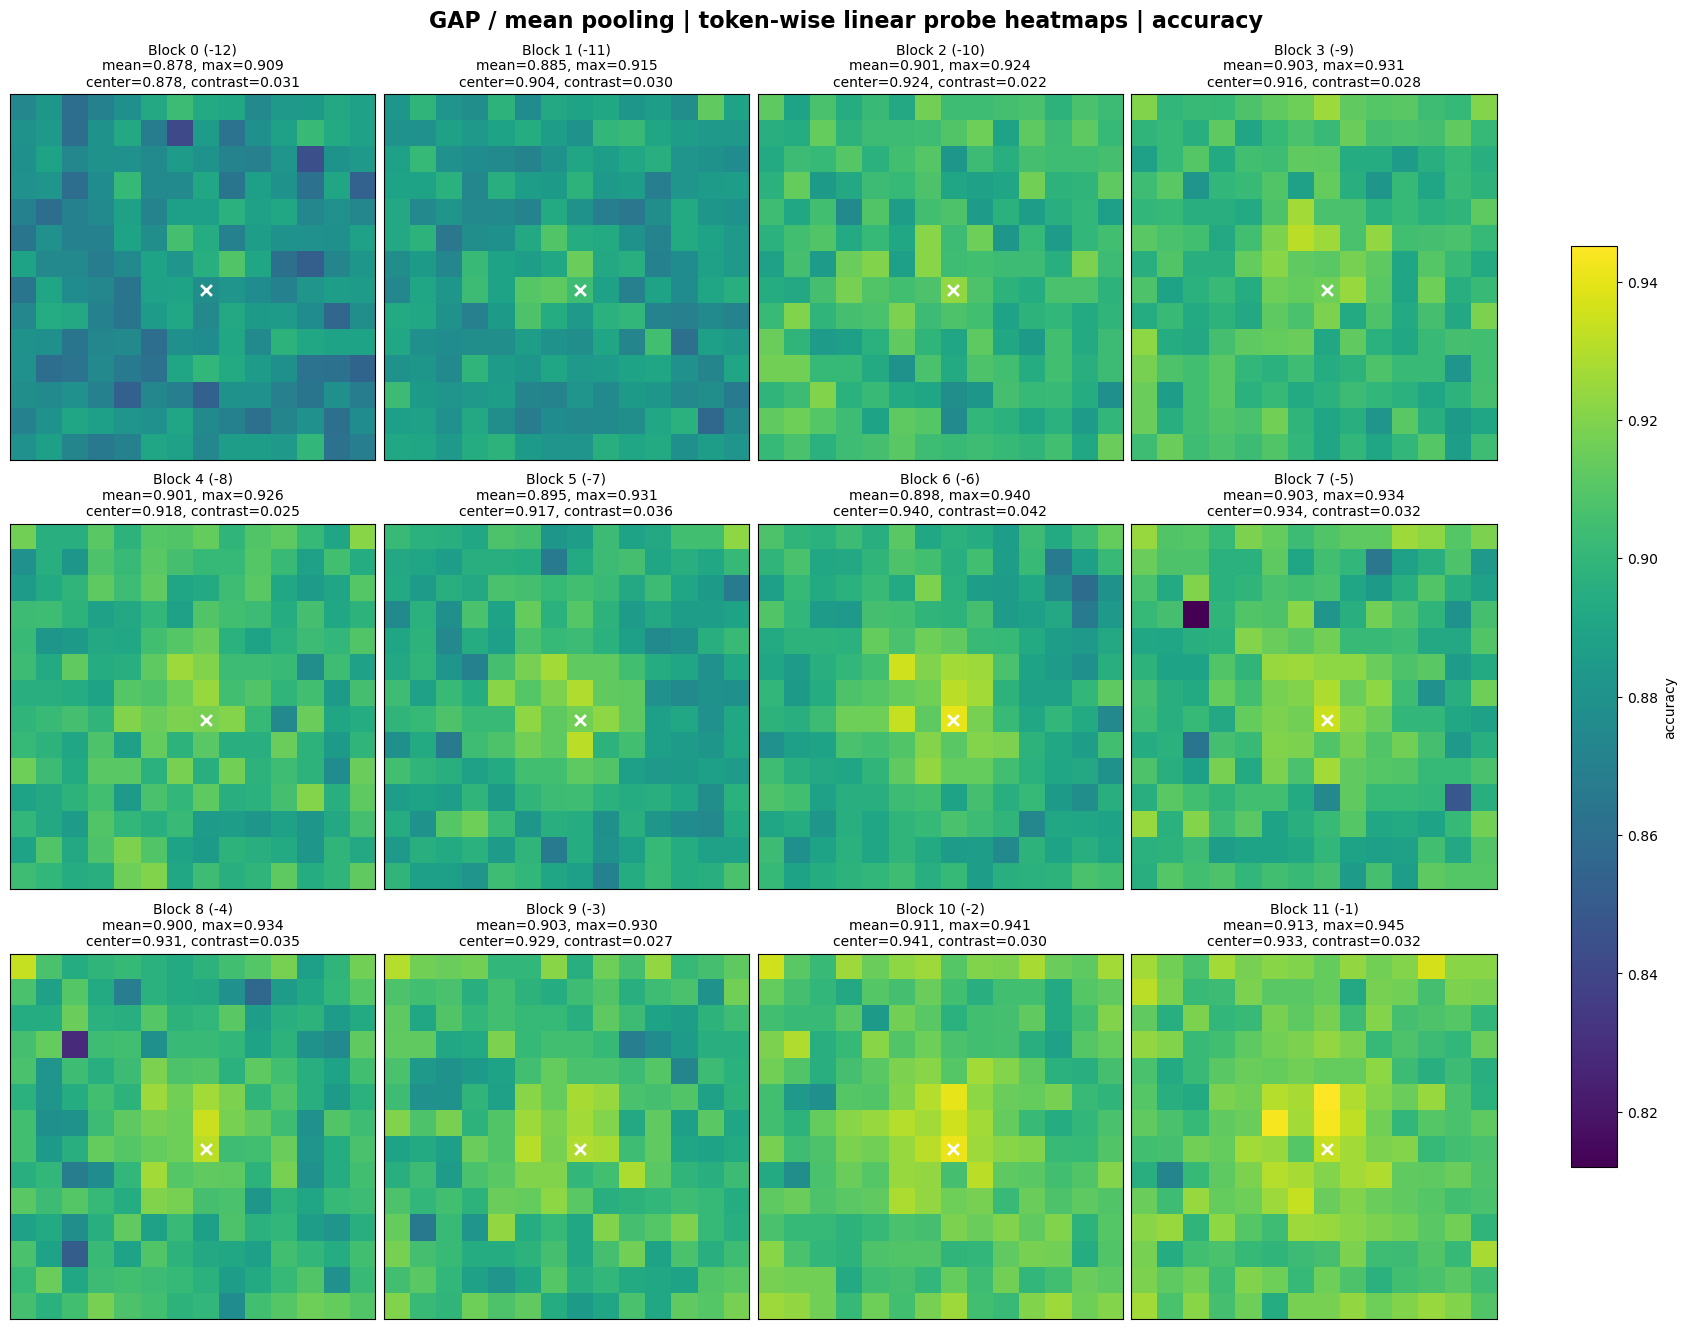

In [9]:
from matplotlib.backends.backend_pdf import PdfPages


def get_metric_value(summary_df, block, metric, column):
    row = summary_df[(summary_df["block"] == block) & (summary_df["metric"] == metric)]
    if len(row) == 0:
        return np.nan
    return float(row.iloc[0][column])


def plot_all_block_heatmaps_to_pdf(
    results,
    summary_df,
    metric="balanced_accuracy",
    pooling_name="GAP / mean pooling",
    out_pdf=None,
    shared_scale=True,
    ncols=4,
):
    blocks = list(results.keys())
    maps = [results[b][metric] for b in blocks]

    if shared_scale:
        vmin = min(m.min() for m in maps)
        vmax = max(m.max() for m in maps)
    else:
        vmin = vmax = None

    n_blocks = len(blocks)
    nrows = int(np.ceil(n_blocks / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.2 * ncols, 4.4 * nrows),
        constrained_layout=True,
    )
    axes = np.array(axes).reshape(-1)
    last_im = None

    for ax, b, m in zip(axes, blocks, maps):
        resolved_idx = results[b]["idx"]
        neg_idx = resolved_idx - len(blocks)
        mean_val = get_metric_value(summary_df, b, metric, "mean")
        max_val = get_metric_value(summary_df, b, metric, "max")
        center_val = get_metric_value(summary_df, b, metric, "center_value")
        spatial_contrast = get_metric_value(summary_df, b, metric, "spatial_contrast")

        last_im = ax.imshow(m, vmin=vmin, vmax=vmax)
        ax.set_title(
            f"Block {resolved_idx} ({neg_idx})\n"
            f"mean={mean_val:.3f}, max={max_val:.3f}\n"
            f"center={center_val:.3f}, contrast={spatial_contrast:.3f}",
            fontsize=10,
        )
        ax.set_xticks([])
        ax.set_yticks([])

        h, w = m.shape
        ax.scatter([w // 2], [h // 2], marker="x", s=60, linewidths=2, c="white")

    for ax in axes[len(blocks):]:
        ax.axis("off")

    fig.suptitle(
        f"{pooling_name} | token-wise linear probe heatmaps | {metric}",
        fontsize=16,
        fontweight="bold",
    )

    if shared_scale and last_im is not None:
        fig.colorbar(last_im, ax=axes[:len(blocks)].tolist(), shrink=0.75, label=metric)

    if out_pdf is not None:
        with PdfPages(out_pdf) as pdf:
            pdf.savefig(fig)
        print("Saved PDF:", out_pdf)

    plt.show()
    return fig


for short_name, pack in ALL_RESULTS.items():
    scenario = pack["scenario"]
    results = pack["results"]
    summary_df = pack["summary"]
    out_dir = pack["out_dir"]

    for metric in ["balanced_accuracy", "accuracy"]:
        pdf_path = out_dir / f"token_probe_all_blocks_{short_name}_{metric}.pdf"
        plot_all_block_heatmaps_to_pdf(
            results=results,
            summary_df=summary_df,
            metric=metric,
            pooling_name=scenario["pooling_name"],
            out_pdf=pdf_path,
            shared_scale=True,
            ncols=4,
        )


## 7. Plot block curves

These curves make it easier to compare CLS vs GAP across blocks.

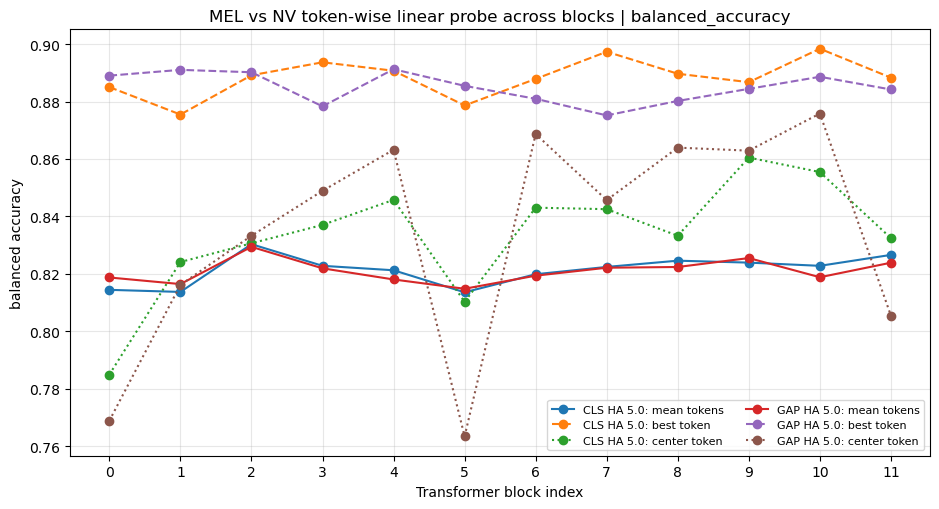

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/token_probe_block_analysis/token_probe_curve_combined_balanced_accuracy.png


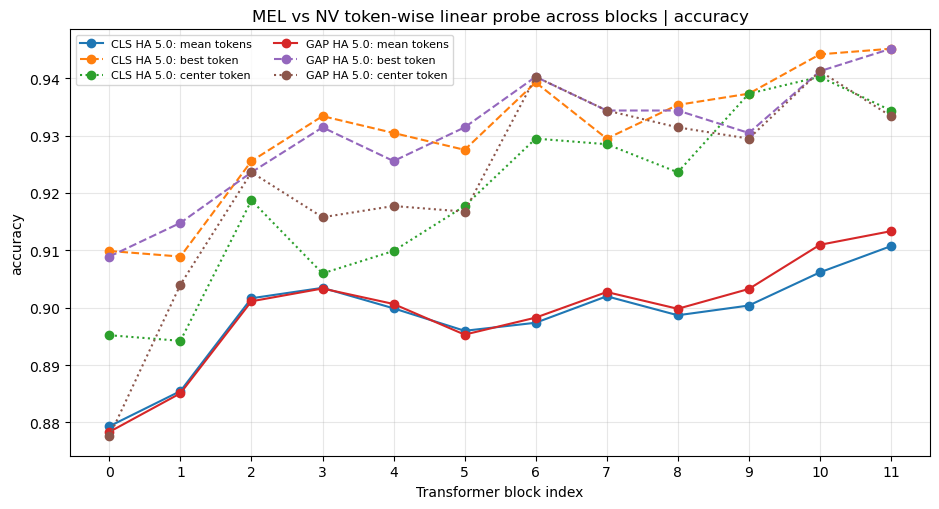

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/token_probe_block_analysis/token_probe_curve_combined_accuracy.png


In [10]:
def plot_block_curves_combined(summary_df, metric="balanced_accuracy"):
    sub = summary_df[summary_df["metric"] == metric].copy()
    sub = sub.sort_values(["short_name", "resolved_index"])

    plt.figure(figsize=(9.5, 5.2))
    for short_name, group in sub.groupby("short_name"):
        label_base = group["model"].iloc[0]
        plt.plot(group["resolved_index"], group["mean"], marker="o", label=f"{label_base}: mean tokens")
        plt.plot(group["resolved_index"], group["max"], marker="o", linestyle="--", label=f"{label_base}: best token")
        plt.plot(group["resolved_index"], group["center_value"], marker="o", linestyle=":", label=f"{label_base}: center token")

    plt.xlabel("Transformer block index")
    plt.ylabel(metric.replace("_", " "))
    plt.title(f"MEL vs NV token-wise linear probe across blocks | {metric}")
    plt.xticks(sorted(sub["resolved_index"].unique()))
    plt.legend(fontsize=8, ncols=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = OUT_ROOT / f"token_probe_curve_combined_{metric}.png"
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


plot_block_curves_combined(combined_summary_df, metric="balanced_accuracy")
plot_block_curves_combined(combined_summary_df, metric="accuracy")


## 8. Best blocks table

This ranks blocks by mean token performance. Use this only as support, not as the only block selection criterion.

In [11]:
best_blocks = (
    combined_summary_df
    .sort_values(["model", "metric", "mean"], ascending=[True, True, False])
    .groupby(["model", "metric"])
    .head(5)
    .reset_index(drop=True)
)

display(best_blocks)
best_path = OUT_ROOT / "token_probe_best_blocks_combined.csv"
best_blocks.to_csv(best_path, index=False)
print("Saved:", best_path)


,model,short_name,pooling,use_mean_pooling,block,resolved_index,negative_index,metric,mean,std,min,max,center_value,spatial_contrast
0,CLS HA 5.0,cls_ha5,CLS token pooling,False,11,11,-1,accuracy,0.910732,0.010848,0.880509,0.945152,0.934378,0.034420
1,CLS HA 5.0,cls_ha5,CLS token pooling,False,10,10,-2,accuracy,0.906159,0.011864,0.878550,0.944172,0.940255,0.038013
2,CLS HA 5.0,cls_ha5,CLS token pooling,False,3,3,-9,accuracy,0.903461,0.009818,0.875612,0.933399,0.905975,0.029938
3,CLS HA 5.0,cls_ha5,CLS token pooling,False,7,7,-5,accuracy,0.901992,0.011790,0.866797,0.929481,0.928501,0.027489
4,CLS HA 5.0,cls_ha5,CLS token pooling,False,2,2,-10,accuracy,0.901647,0.009285,0.878550,0.925563,0.918707,0.023916
5,CLS HA 5.0,cls_ha5,CLS token pooling,False,2,2,-10,balanced_accuracy,0.830324,0.024926,0.761402,0.889139,0.830637,0.058815
6,CLS HA 5.0,cls_ha5,CLS token pooling,False,11,11,-1,balanced_accuracy,0.826592,0.024024,0.760876,0.888306,0.832432,0.061714
7,CLS HA 5.0,cls_ha5,CLS token pooling,False,8,8,-4,balanced_accuracy,0.824578,0.025063,0.741115,0.889665,0.833266,0.065087
8,CLS HA 5.0,cls_ha5,CLS token pooling,False,9,9,-3,balanced_accuracy,0.823904,0.026074,0.743128,0.886728,0.860478,0.062825
9,CLS HA 5.0,cls_ha5,CLS token pooling,False,3,3,-9,balanced_accuracy,0.822790,0.025729,0.760350,0.893653,0.837036,0.070863


Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/token_probe_block_analysis/token_probe_best_blocks_combined.csv


## 9. Practical interpretation guide

Use this together with notebook 02.

### If final blocks are uniformly high
This means many patch tokens contain class information. It can happen because ViT tokens exchange global context through self attention.

### If one block has high mean and high center value
This may indicate strong lesion-centered predictive information, but be careful because HAM10000 lesions are often centered.

### If one block has higher spatial contrast
This block may preserve more spatial specificity. It can be a good candidate for CAM generation.

### If CLS and GAP differ
That supports your thesis story that pooling choice changes the spatial distribution of class information and can affect explanation behavior.

### Recommended decision logic
Do not select the block only from token probes. Combine:
- qualitative CAM focus from notebook 02,
- token-probe maps and curves from this notebook,
- quantitative CAM/mask/perturbation analysis in the next notebook.
